# **RNNS (Recurrent Neural Network)**

- Design for sequential data (time series data) where current output depends not only on the current input but also on previous inputs, it has memory

$$y_{i} = \theta(W_{x}^{t}X_{(t)} + W_{x}^{t}Y_{(t-1)} + b)$$

- Types of RNNs
1. Many to One, Sequence to Single Output, Use: Sentiment Analysis
2. One to many, Vector to Sequence, Use: Image Captioning
3. Encoder(Sequence to vector) + Decoder(Vector to Sequence)

**How RNNs are Trainned?**

1. Forwards pass at each time step t for given sequence $x_{1}, x_{2}.....x_{t}$
$$h_{t} = \theta(W_{x}^{t}X_{(t)} + W_{x}^{t}Y_{(t-1)} + b)$$
$$y_{t} = g(W_{y}h_{t})$$

2. Compute Loss
- Many to many:
$$L = \sigma_{T}^{t=1}l(y_{t}, y^{true}_{t})$$
$$L = l(y_{T}, y^{true})$$

3. Backpropogation Through Time (BPTT)
- Calculate the Gradients
- Update the weights using the gradients by optimizers like (adam, nadam etc)
- Reduce the loss (mae)

# **Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

c:\Python311\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


# **Loading and Preparing Data**

In [2]:
df = pd.read_csv('Datasets\CTA_-_Ridership_-_Daily_Boarding_Totals_20260328.csv', parse_dates=["service_date"])

In [3]:
df.columns = ["date", "day_type", "bus", "rail", "total"]

df["bus"] = df["bus"].str.replace(",", "").astype(int)
df["rail"] = df["rail"].str.replace(",", "").astype(int)

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").set_index("date")

df = df.drop("total", axis=1)
df = df.drop_duplicates()

In [4]:
df.head()

,day_type,bus,rail
date,,,
2001-01-01,U,297192,126455
2001-01-02,W,780827,501952
2001-01-03,W,824923,536432
2001-01-04,W,870021,550011
2001-01-05,W,890426,557917


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9162 entries, 2001-01-01 to 2026-01-31
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   day_type  9162 non-null   object
 1   bus       9162 non-null   int32 
 2   rail      9162 non-null   int32 
dtypes: int32(2), object(1)
memory usage: 214.7+ KB


# **Analysis**

## **Yearly Seasonality and Long-term Trends**

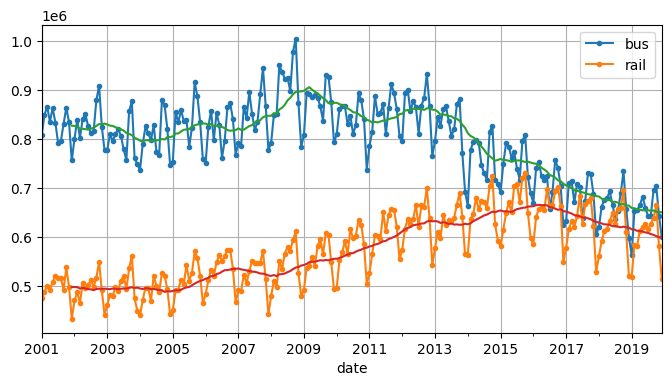

In [6]:
period = slice("2001", "2019")

# ensure the index is datetime for resample
df_monthly = df.select_dtypes(include="number").resample("ME").mean()
rolling_average_12_months = df_monthly.loc[period].rolling(window=12).mean()

fig, ax = plt.subplots(figsize=(8, 4))
df_monthly[period].plot(ax=ax, marker=".")
rolling_average_12_months.plot(ax=ax, grid=True, legend=False)

plt.show()

## **Monthly Seasonlity**

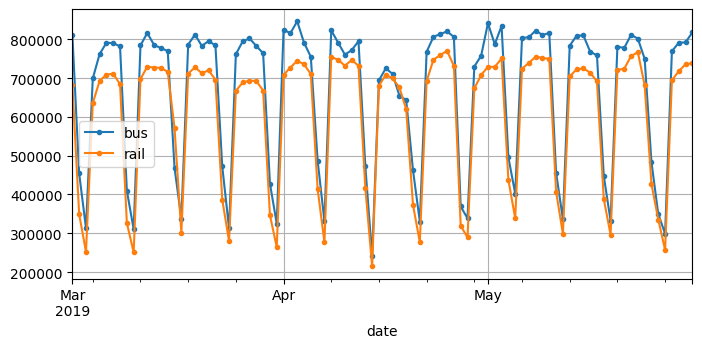

In [7]:
df["2019-03":"2019-05"].plot(grid=True, marker=".", figsize=(8, 3.5))

plt.show()

There is some weekly trends in the dataset, Since there is weekly sesonality we can use SARIMA over this dataset

## **Stationarity**

1. Some time-series models, such as such as ARIMA, assume that the underlying data is stationary. Stationarity describes that the time-series has

- constant mean and mean is not time-dependent
- constant variance and variance is not time-dependent
- constant covariance and covariance is not time-dependent

2. If a time series has a specific (stationary) behavior over a given time interval, then it can be assumed that the time series will behave the same at a later time.

3. Time series with trend and/or seasonality are not stationary. Trend indicates that the mean is not constant over time and seasonality indicates that the variance is not constant over time.

The check for stationarity can be done via three different approaches:

1. visually: plot time series and check for trends or seasonality
2. basic statistics: split time series and compare the mean and variance of each partition
3. statistical test: Augmented Dickey Fuller test

### **1. Visually**

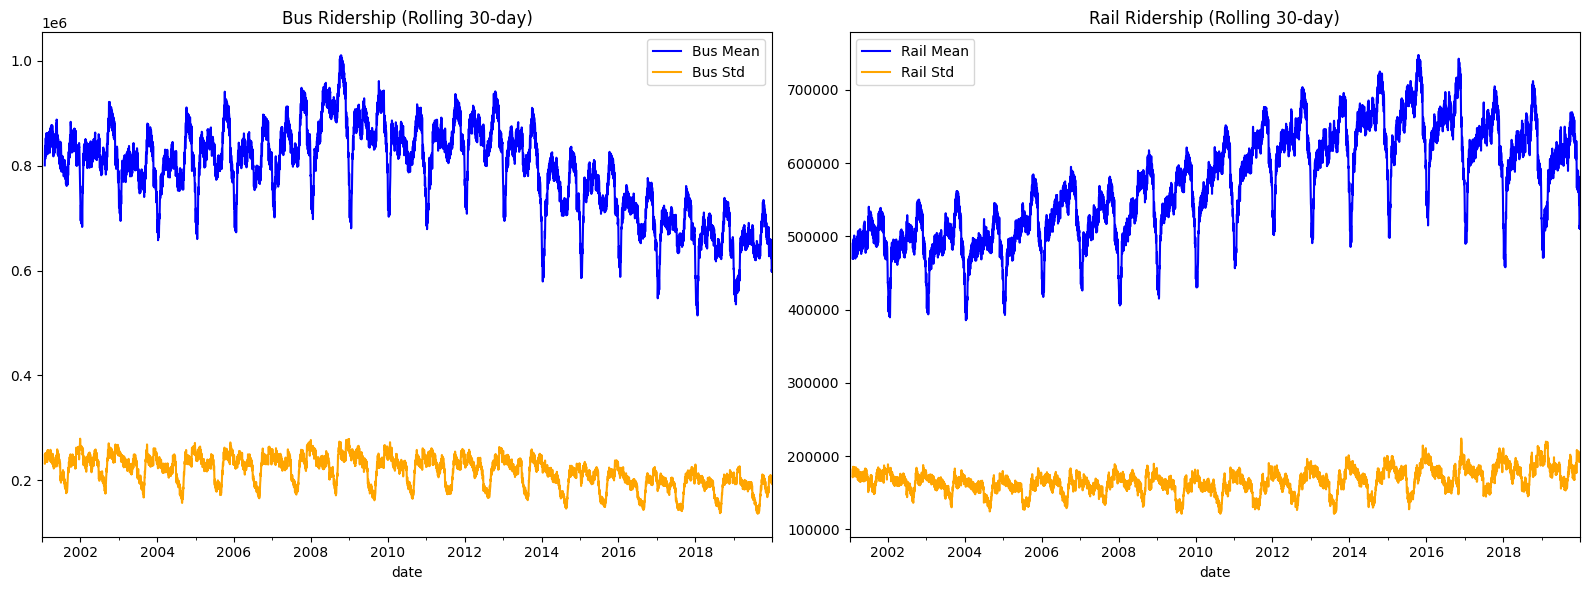

In [8]:
df_range = df['2001':'2019']
rolling = 30

fig, ax = plt.subplots(ncols=2, nrows=1, sharex=True, figsize=(16,6))

# Left plot: Bus mean + std
df_range["bus"].rolling(rolling).mean().plot(ax=ax[0], color="blue", label="Bus Mean")
df_range["bus"].rolling(rolling).std().plot(ax=ax[0], color="orange", label="Bus Std")
ax[0].set_title(f"Bus Ridership (Rolling {rolling}-day)")
ax[0].legend()

# Right plot: Rail mean + std
df_range["rail"].rolling(rolling).mean().plot(ax=ax[1], color="blue", label="Rail Mean")
df_range["rail"].rolling(rolling).std().plot(ax=ax[1], color="orange", label="Rail Std")
ax[1].set_title(f"Rail Ridership (Rolling {rolling}-day)")
ax[1].legend()

plt.tight_layout()
plt.show()


In [9]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df_range["bus"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("The time series is stationary.")
else:
    print("The time series is not stationary.")

ADF Statistic: -4.590723224236878
p-value: 0.00013435185810766032
The time series is stationary.


## **Decompose**

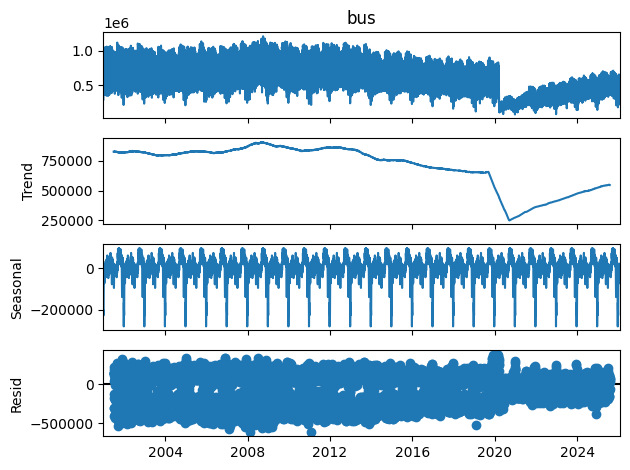

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(df["bus"], model="additive", period=365)
fig = result.plot()

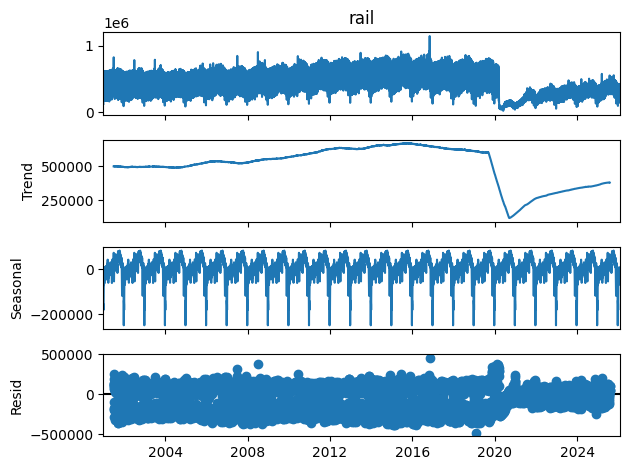

In [11]:
result = seasonal_decompose(df["rail"], model="additive", period=365)
fig = result.plot()

## **Lag**

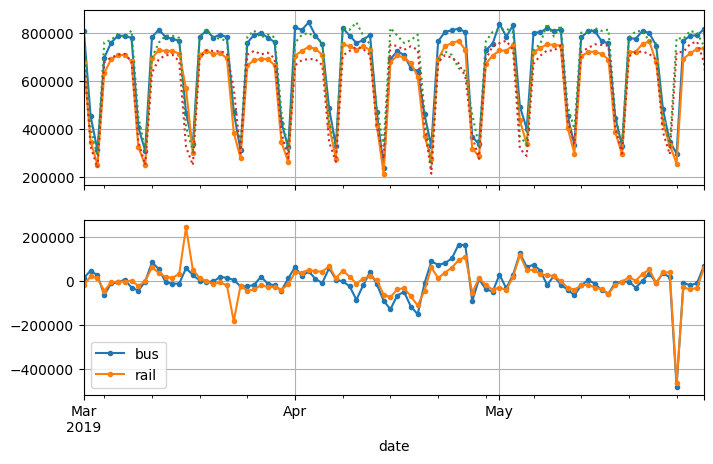

In [12]:
diff_7 = df[["bus", "rail"]].diff(7)["2019-03":"2019-05"]

fig, axs = plt.subplots(2, 1, sharex=True, figsize=(8, 5))
df.plot(ax=axs[0], legend=False, marker=".")  # original time series
df.shift(7).plot(ax=axs[0], grid=True, legend=False, linestyle=":")  # lagged
diff_7.plot(ax=axs[1], grid=True, marker=".")  # 7-day difference time series
axs[0].set_ylim([170_000, 900_000])

plt.show()

## **Autocorrelation Analysis**

1. This EDA step is especially important when using ARIMA. The autocorrelation analysis helps to identify the AR and MA parameters for the ARIMA model.

2. Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF)

- Autocorrelation Function (ACF): Correlation between time series with a lagged version of itself. The autocorrelation function starts a lag 0, which is the correlation of the time series with itself and therefore results in a correlation of 1. -> MA parameter is q significant lags
- Partial Autocorrelation Function (PACF): Additional correlation explained by each successive lagged term -> AR parameter is p significant lags
Autocorrelation helps in detecting seasonality.

3. As we can infer from the graph above, the autocorrelation continues to decrease as the lag increases, confirming that there is no linear association between observations separated by larger lags.

4. For the AR process, we expect that the ACF plot will gradually decrease and simultaneously the PACF should have a sharp drop after p significant lags. To define a MA process, we expect the opposite from the ACF and PACF plots, meaning that: the ACF should show a sharp drop after a certain q number of lags while PACF should show a geometric or gradual decreasing trend.

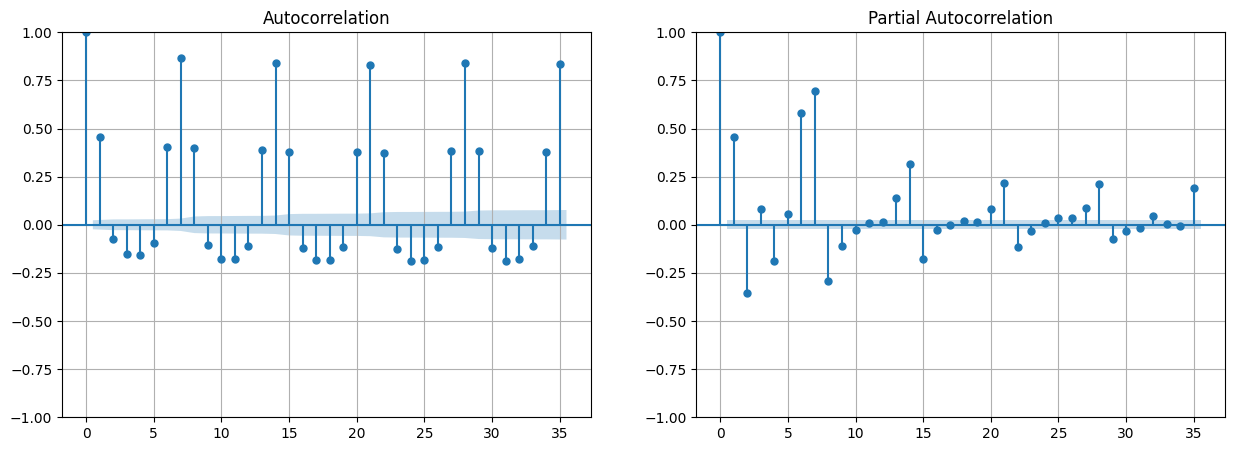

In [13]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
plot_acf(df[period]["rail"], ax=axs[0], lags=35)
axs[0].grid()
plot_pacf(df[period]["rail"], ax=axs[1], lags=35, method="ywm")
axs[1].grid()
plt.show()

# **Models**

## **Models for Univariate Time Series**

1. Stochastic Models
- Naive Approach
- Moving Average
- Exponential Smoothing
- ARIMA
- Prophet

2. Deep Learning
- LSTM
- GRU


In [14]:
diff_7["naive"] = diff_7["rail"].shift(1) # naive forecast
diff_7["seasonal_naive"] = diff_7["rail"].shift(7) # seasonal naive forecast
diff_7 = diff_7.dropna()

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae_naive = mean_absolute_error(diff_7["rail"], diff_7["naive"])
rmse_naive = np.sqrt(mean_squared_error(diff_7["rail"], diff_7["naive"]))

mae_seasonal = mean_absolute_error(diff_7["rail"], diff_7["seasonal_naive"])
rmse_seasonal = np.sqrt(mean_squared_error(diff_7["rail"], diff_7["seasonal_naive"]))

print("Naive     → MAE:", mae_naive, "RMSE:", rmse_naive)
print("Seasonal  → MAE:", mae_seasonal, "RMSE:", rmse_seasonal)

Naive     → MAE: 45881.211764705884 RMSE: 90873.95351694566
Seasonal  → MAE: 73575.43529411765 RMSE: 105274.91371262197


## **ARIMA**

In [16]:
from statsmodels.tsa.arima.model import ARIMA

origin, start_date, end_date = "2019-01-01", "2019-03-01", "2019-05-31"
time_period = pd.date_range(start_date, end_date)
rail_series = df.loc[origin:end_date]["rail"].asfreq("D")
y_preds = []
for today in time_period.shift(-1):
    model = ARIMA(rail_series[origin:today],  # train on data up to "today"
                  order=(1, 0, 0),
                  seasonal_order=(0, 1, 1, 7))
    model = model.fit()  # note that we retrain the model every day!
    y_pred = model.forecast().iloc[0]
    y_preds.append(y_pred)

y_preds = pd.Series(y_preds, index=time_period)
mae = (y_preds - rail_series[time_period]).abs().mean()

In [17]:
actual = rail_series[time_period]

comparison = pd.DataFrame({
    "Actual": actual,
    "Predicted": y_preds
})

comparison

,Actual,Predicted
2019-03-01,682969,696955.515263
2019-03-02,349392,342139.360984
2019-03-03,252150,253320.415577
2019-03-04,635353,633245.753012
2019-03-05,692945,696723.448659
...,...,...
2019-05-27,256757,736799.259407
2019-05-28,694292,403824.542296
2019-05-29,717681,721311.483001
2019-05-30,735508,726614.005084


In [18]:
mae

32040.720090488467

In [19]:
df["rail"].loc["2019-06-01"]

379044

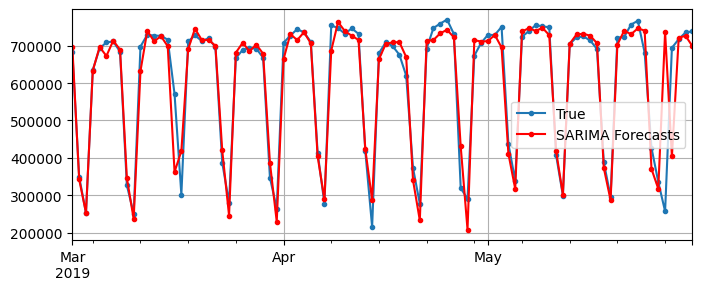

In [20]:
fig, ax = plt.subplots(figsize=(8, 3))
rail_series.loc[time_period].plot(label="True", ax=ax, marker=".", grid=True)
ax.plot(y_preds, color="r", marker=".", label="SARIMA Forecasts")
plt.legend()
plt.show()

# **Spliting the Dataset**

In [21]:
rail_train = df["rail"]["2016-01":"2018-12"] / 1e6
rail_valid = df["rail"]["2019-01":"2019-05"] / 1e6
rail_test = df["rail"]["2019-06":] / 1e6

In [22]:
seq_length = 56
tf.random.set_seed(42)

train_ds = tf.keras.utils.timeseries_dataset_from_array(
    rail_train.to_numpy(),
    targets=rail_train[seq_length:],
    sequence_length=seq_length,
    batch_size=32,
    shuffle=True,
    seed=42
)

valid_ds = tf.keras.utils.timeseries_dataset_from_array(
    rail_valid.to_numpy(),
    targets=rail_valid[seq_length:],
    sequence_length=seq_length,
    batch_size=32
)

In [23]:
# simple Linear model

tf.random.set_seed(42)

linear_model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=[seq_length])
])

early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    monitor="val_mae", 
    patience=50, 
    restore_best_weights=True
)

opt = tf.keras.optimizers.SGD(learning_rate=0.02, momentum=0.9)
linear_model.compile(loss=tf.keras.losses.Huber(), optimizer=opt, metrics=["mae"])

history = linear_model.fit(train_ds, validation_data=valid_ds, epochs=500,
                    callbacks=[early_stopping_cb])


Epoch 1/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0358 - mae: 0.2016 - val_loss: 0.0094 - val_mae: 0.1075
Epoch 2/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0116 - mae: 0.1151 - val_loss: 0.0062 - val_mae: 0.0862
Epoch 3/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0098 - mae: 0.1027 - val_loss: 0.0064 - val_mae: 0.0858
Epoch 4/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0075 - mae: 0.0895 - val_loss: 0.0050 - val_mae: 0.0755
Epoch 5/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0069 - mae: 0.0853 - val_loss: 0.0048 - val_mae: 0.0703
Epoch 6/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0070 - mae: 0.0863 - val_loss: 0.0045 - val_mae: 0.0672
Epoch 7/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0059 - mae: 0.0779 - val_loss: 0.0043 - val_mae: 0.0655
Epoch 8/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0058 - mae: 0.0777 - val_loss: 0.0041 - val_mae: 0.0644
Epoch 9/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.00

In [24]:
valid_loss, valid_mae = linear_model.evaluate(valid_ds)
valid_mae * 1e6

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0023 - mae: 0.0379


37931.95262551308

# **Using a Simple RNN**

In [25]:
tf.random.set_seed(42)

simple_rnn_model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(1, input_shape=[None, 1])
])

In [26]:
def fit_and_evaluate(model, train_set, valid_set, learning_rate, epochs=500):
    early_stopping_cb = tf.keras.callbacks.EarlyStopping(
        monitor="val_mae",
        patience=50,
        restore_best_weights=True
    )

    opt = tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.9)
    model.compile(loss=tf.keras.losses.Huber(), optimizer=opt, metrics=["mae"])
    history = model.fit(
        train_set,
        validation_data=valid_set,
        epochs=epochs,
        callbacks=[early_stopping_cb]
    )

    valid_loss, valid_mae = model.evaluate(valid_set)
    return valid_mae * 1e6

In [27]:
fit_and_evaluate(simple_rnn_model, train_ds, valid_ds, learning_rate=0.02)

Epoch 1/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0293 - mae: 0.2031 - val_loss: 0.0119 - val_mae: 0.1149
Epoch 2/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0117 - mae: 0.1183 - val_loss: 0.0120 - val_mae: 0.1138
Epoch 3/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0115 - mae: 0.1198 - val_loss: 0.0116 - val_mae: 0.1140
Epoch 4/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0114 - mae: 0.1196 - val_loss: 0.0116 - val_mae: 0.1136
Epoch 5/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0113 - mae: 0.1194 - val_loss: 0.0115 - val_mae: 0.1133
Epoch 6/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0112 - mae: 0.1194 - val_loss: 0.0114 - val_mae: 0.1130
Epoch 7/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0112 - mae: 0.1194 - val_loss: 0.0113 - val_mae: 0.1128
Epoch 8/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0111 - mae: 0.1188 - val_loss: 0.0112 - val_mae: 0.1124
Epoch 9/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - lo

102729.54404354095

In [28]:
tf.random.set_seed(42)  # extra code – ensures reproducibility
univar_model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(32, input_shape=[None, 1]),
    tf.keras.layers.Dense(1)  # no activation function by default
])

In [29]:
fit_and_evaluate(univar_model, train_ds, valid_ds, learning_rate=0.05)

Epoch 1/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - loss: 0.3140 - mae: 0.6720 - val_loss: 0.5865 - val_mae: 1.0806
Epoch 2/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.1287 - mae: 0.4049 - val_loss: 0.0529 - val_mae: 0.2727
Epoch 3/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0352 - mae: 0.2200 - val_loss: 0.0351 - val_mae: 0.1969
Epoch 4/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0241 - mae: 0.1769 - val_loss: 0.0161 - val_mae: 0.1657
Epoch 5/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0265 - mae: 0.1873 - val_loss: 0.0158 - val_mae: 0.1479
Epoch 6/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0190 - mae: 0.1658 - val_loss: 0.0327 - val_mae: 0.1842
Epoch 7/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0255 - mae: 0.1828 - val_loss: 0.0157 - val_mae: 0.1567
Epoch 8/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0197 - mae: 0.1661 - val_loss: 0.0165 - val_mae: 0.1370
Epoch 9/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - lo

122538.64854574203

# **Deep RNNs**

In [30]:
tf.random.set_seed(42)

deep_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=[None, 1]),
    tf.keras.layers.SimpleRNN(32, return_sequences=True),
    tf.keras.layers.SimpleRNN(32, return_sequences=True),
    tf.keras.layers.SimpleRNN(32),
    tf.keras.layers.Dense(1)
])

In [31]:
fit_and_evaluate(deep_model, train_ds, valid_ds, learning_rate=0.01)

Epoch 1/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 94ms/step - loss: 0.0588 - mae: 0.2515 - val_loss: 0.0258 - val_mae: 0.2150
Epoch 2/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.0197 - mae: 0.1631 - val_loss: 0.0140 - val_mae: 0.1311
Epoch 3/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.0158 - mae: 0.1509 - val_loss: 0.0129 - val_mae: 0.1042
Epoch 4/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.0124 - mae: 0.1261 - val_loss: 0.0063 - val_mae: 0.0950
Epoch 5/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.0073 - mae: 0.0921 - val_loss: 0.0032 - val_mae: 0.0624
Epoch 6/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0052 - mae: 0.0731 - val_loss: 0.0039 - val_mae: 0.0646
Epoch 7/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0048 - mae: 0.0678 - val_loss: 0.0027 - val_mae: 0.0543
Epoch 8/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.0045 - mae: 0.0640 - val_loss: 0.0041 - val_mae: 0.0701
Epoch 9/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - l

31216.178089380264

In [32]:
models = {
    "Linear": linear_model,
    "Simple_RNN": simple_rnn_model,
    "Univar_RNN": univar_model,
    "Deep_RNN": deep_model,
}

for key, value in models.items():
    valid_loss, valid_mae = value.evaluate(valid_ds, verbose=0)
    print(f"{key} → MAE: {valid_mae * 1e6:.2f}")

Linear → MAE: 37931.95
Simple_RNN → MAE: 102729.54
Univar_RNN → MAE: 122538.65
Deep_RNN → MAE: 31216.18


# **Multivariate time series**

In [33]:
df_mulvar = df[["bus", "rail"]] / 1e6  # use both bus & rail series as input
df_mulvar["next_day_type"] = df["day_type"].shift(-1)  # we know tomorrow's type
df_mulvar = pd.get_dummies(df_mulvar, dtype=float)  # one-hot encode the day type

In [34]:
df_mulvar.head()

,bus,rail,next_day_type_A,next_day_type_U,next_day_type_W
date,,,,,
2001-01-01,0.297192,0.126455,0.0,0.0,1.0
2001-01-02,0.780827,0.501952,0.0,0.0,1.0
2001-01-03,0.824923,0.536432,0.0,0.0,1.0
2001-01-04,0.870021,0.550011,0.0,0.0,1.0
2001-01-05,0.890426,0.557917,1.0,0.0,0.0


In [35]:
mulvar_train = df_mulvar["2016-01":"2018-12"]
mulvar_valid = df_mulvar["2019-01":"2019-05"]
mulvar_test = df_mulvar["2019-06":]

In [36]:
tf.random.set_seed(42)

train_mulvar_ds = tf.keras.utils.timeseries_dataset_from_array(
    mulvar_train.to_numpy(),  # use all 5 columns as input
    targets=mulvar_train["rail"][seq_length:],  # forecast only the rail series
    sequence_length=seq_length,
    batch_size=32,
    shuffle=True,
    seed=42
)
valid_mulvar_ds = tf.keras.utils.timeseries_dataset_from_array(
    mulvar_valid.to_numpy(),
    targets=mulvar_valid["rail"][seq_length:],
    sequence_length=seq_length,
    batch_size=32
)

In [37]:
tf.random.set_seed(42)

mulvar_model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(32, input_shape=[None, 5]),
    tf.keras.layers.Dense(1)
])

In [38]:
fit_and_evaluate(mulvar_model, train_mulvar_ds, valid_mulvar_ds, learning_rate=0.05)

Epoch 1/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - loss: 0.0649 - mae: 0.2472 - val_loss: 0.0083 - val_mae: 0.1228
Epoch 2/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0029 - mae: 0.0591 - val_loss: 0.0030 - val_mae: 0.0696
Epoch 3/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0018 - mae: 0.0446 - val_loss: 0.0017 - val_mae: 0.0502
Epoch 4/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0014 - mae: 0.0375 - val_loss: 0.0015 - val_mae: 0.0456
Epoch 5/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0014 - mae: 0.0374 - val_loss: 6.3408e-04 - val_mae: 0.0255
Epoch 6/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0015 - mae: 0.0401 - val_loss: 8.5861e-04 - val_mae: 0.0315
Epoch 7/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0014 - mae: 0.0377 - val_loss: 6.5312e-04 - val_mae: 0.0255
Epoch 8/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0014 - mae: 0.0371 - val_loss: 6.1939e-04 - val_mae: 0.0240
Epoch 9/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1

23368.533700704575

In [39]:
# forecast both bus and rail

tf.random.set_seed(42)

seq_length = 56
train_multask_ds = tf.keras.utils.timeseries_dataset_from_array(
    mulvar_train.to_numpy(),
    targets=mulvar_train[["bus", "rail"]][seq_length:],  # 2 targets per day
    sequence_length=seq_length,
    batch_size=32,
    shuffle=True,
    seed=42
)
valid_multask_ds = tf.keras.utils.timeseries_dataset_from_array(
    mulvar_valid.to_numpy(),
    targets=mulvar_valid[["bus", "rail"]][seq_length:],
    sequence_length=seq_length,
    batch_size=32
)

tf.random.set_seed(42)
multask_model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(32, input_shape=[None, 5]),
    tf.keras.layers.Dense(2)
])

fit_and_evaluate(multask_model, train_multask_ds, valid_multask_ds,
                 learning_rate=0.02)

Epoch 1/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.0434 - mae: 0.2125 - val_loss: 0.0054 - val_mae: 0.0828
Epoch 2/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0037 - mae: 0.0618 - val_loss: 0.0014 - val_mae: 0.0360
Epoch 3/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0024 - mae: 0.0471 - val_loss: 0.0013 - val_mae: 0.0377
Epoch 4/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0020 - mae: 0.0432 - val_loss: 0.0011 - val_mae: 0.0343
Epoch 5/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0017 - mae: 0.0405 - val_loss: 0.0013 - val_mae: 0.0399
Epoch 6/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0016 - mae: 0.0398 - val_loss: 0.0012 - val_mae: 0.0386
Epoch 7/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0015 - mae: 0.0390 - val_loss: 8.3138e-04 - val_mae: 0.0304
Epoch 8/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0015 - mae: 0.0384 - val_loss: 0.0014 - val_mae: 0.0434
Epoch 9/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step 

25057.81687796116

In [40]:
# Naive forecast for bus series (shifted by 7 days)

bus_naive = mulvar_valid["bus"].shift(7)[seq_length:]
bus_target = mulvar_valid["bus"][seq_length:]
(bus_naive - bus_target).abs().mean() * 1e6

43441.63157894738

In [41]:
# evaluates the multitask RNN's forecasts both bus and rail

Y_preds_valid = multask_model.predict(valid_multask_ds)
for idx, name in enumerate(["bus", "rail"]):
    mae = 1e6 * tf.keras.metrics.MeanAbsoluteError()(
        mulvar_valid[name][seq_length:], Y_preds_valid[:, idx])
    print(name, int(mae))

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 217ms/step
bus 26715
rail 23399


# **Forecasting Several Steps Ahead**

Predicting 14 days ahead using the previous model forecast

In [42]:
X = rail_valid.to_numpy()[np.newaxis, :seq_length, np.newaxis]
for step_ahead in range(14):
    y_pred_one = univar_model.predict(X)
    X = np.concatenate([X, y_pred_one.reshape(1, 1, 1)], axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


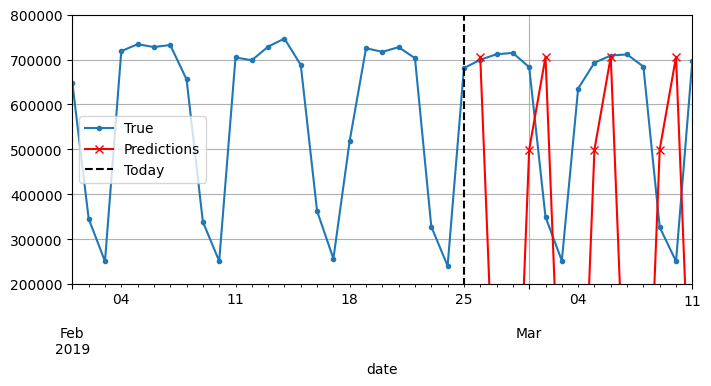

In [43]:
'''The forecasts start on 2019-02-26, as it is the 57th day of 2019, and they end
on 2019-03-11. That's 14 days in total.'''

Y_pred = pd.Series(X[0, -14:, 0],
                   index=pd.date_range("2019-02-26", "2019-03-11"))

fig, ax = plt.subplots(figsize=(8, 3.5))
(rail_valid * 1e6)["2019-02-01":"2019-03-11"].plot(
    label="True", marker=".", ax=ax)
(Y_pred * 1e6).plot(
    label="Predictions", grid=True, marker="x", color="r", ax=ax)
ax.vlines("2019-02-25", 0, 1e6, color="k", linestyle="--", label="Today")
ax.set_ylim([200_000, 800_000])
plt.legend(loc="center left")

plt.show()

This approach assumes the model can accurately predict future values using only its own previous predictions as context. In reality, errors can compound—if the first prediction is slightly off, that error feeds into the next prediction, potentially amplifying uncertainty over the 14-day horizon. This is why forecasts typically become less reliable farther into the future. For mission-critical applications, consider techniques like ensemble methods or probabilistic forecasting to quantify this uncertainty.


Now let's create an RNN that predicts all 14 next values at once:

In [44]:
tf.random.set_seed(42) 

def split_inputs_and_targets(mulvar_series, ahead=14, target_col=1):
    return mulvar_series[:, :-ahead], mulvar_series[:, -ahead:, target_col]

ahead_train_ds = tf.keras.utils.timeseries_dataset_from_array(
    mulvar_train.to_numpy(),
    targets=None,
    sequence_length=seq_length + 14,
    batch_size=32,
    shuffle=True,
    seed=42
).map(split_inputs_and_targets)

ahead_valid_ds = tf.keras.utils.timeseries_dataset_from_array(
    mulvar_valid.to_numpy(),
    targets=None,
    sequence_length=seq_length + 14,
    batch_size=32
).map(split_inputs_and_targets)

In [45]:
tf.random.set_seed(42)

ahead_model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(32, input_shape=[None, 5]),
    tf.keras.layers.Dense(14)
])

In [46]:
fit_and_evaluate(ahead_model, ahead_train_ds, ahead_valid_ds, learning_rate=0.02)

Epoch 1/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - loss: 0.0956 - mae: 0.3287 - val_loss: 0.0295 - val_mae: 0.1804
Epoch 2/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0218 - mae: 0.1618 - val_loss: 0.0154 - val_mae: 0.1343
Epoch 3/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0151 - mae: 0.1353 - val_loss: 0.0116 - val_mae: 0.1163
Epoch 4/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0122 - mae: 0.1213 - val_loss: 0.0089 - val_mae: 0.1030
Epoch 5/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0100 - mae: 0.1088 - val_loss: 0.0070 - val_mae: 0.0912
Epoch 6/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0084 - mae: 0.0984 - val_loss: 0.0057 - val_mae: 0.0813
Epoch 7/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0073 - mae: 0.0896 - val_loss: 0.0045 - val_mae: 0.0728
Epoch 8/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0065 - mae: 0.0831 - val_loss: 0.0038 - val_mae: 0.0666
Epoch 9/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - lo

34227.82942652702

In [47]:
X = mulvar_valid.to_numpy()[np.newaxis, :seq_length]  # shape [1, 56, 5]
Y_pred = ahead_model.predict(X)  # shape [1, 14]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step


Now let's create an RNN that predicts the next 14 steps at each time step. That is, instead of just forecasting time steps 56 to 69 based on time steps 0 to 55, it will forecast time steps 1 to 14 at time step 0, then time steps 2 to 15 at time step 1, and so on, and finally it will forecast time steps 56 to 69 at the last time step. Notice that the model is causal: when it makes predictions at any time step, it can only see past time steps.

To prepare the datasets, we can use to_windows() twice, to get sequences of consecutive windows, like this:

In [48]:
def to_windows(dataset, length):
    dataset = dataset.window(length, shift=1, drop_remainder=True)
    return dataset.flat_map(lambda window_ds: window_ds.batch(length))

In [49]:
my_series = tf.data.Dataset.range(7)
dataset = to_windows(to_windows(my_series, 3), 4)
list(dataset)

[<tf.Tensor: shape=(4, 3), dtype=int64, numpy=
 array([[0, 1, 2],
        [1, 2, 3],
        [2, 3, 4],
        [3, 4, 5]], dtype=int64)>,
 <tf.Tensor: shape=(4, 3), dtype=int64, numpy=
 array([[1, 2, 3],
        [2, 3, 4],
        [3, 4, 5],
        [4, 5, 6]], dtype=int64)>]

In [50]:
dataset = dataset.map(lambda S: (S[:, 0], S[:, 1:]))
list(dataset)

[(<tf.Tensor: shape=(4,), dtype=int64, numpy=array([0, 1, 2, 3], dtype=int64)>,
  <tf.Tensor: shape=(4, 2), dtype=int64, numpy=
  array([[1, 2],
         [2, 3],
         [3, 4],
         [4, 5]], dtype=int64)>),
 (<tf.Tensor: shape=(4,), dtype=int64, numpy=array([1, 2, 3, 4], dtype=int64)>,
  <tf.Tensor: shape=(4, 2), dtype=int64, numpy=
  array([[2, 3],
         [3, 4],
         [4, 5],
         [5, 6]], dtype=int64)>)]

In [51]:
def to_seq2seq_dataset(series, seq_length=56, ahead=14, target_col=1,
                       batch_size=32, shuffle=False, seed=None):
    ds = to_windows(tf.data.Dataset.from_tensor_slices(series), ahead + 1)
    ds = to_windows(ds, seq_length).map(
        lambda S: (S[:, 0], S[:, 1:, target_col]))
    if shuffle:
        ds = ds.shuffle(8 * batch_size, seed=seed)
    return ds.batch(batch_size)

In [52]:
seq2seq_train = to_seq2seq_dataset(mulvar_train, shuffle=True, seed=42)
seq2seq_valid = to_seq2seq_dataset(mulvar_valid)

In [53]:
tf.random.set_seed(42)  # extra code – ensures reproducibility
seq2seq_model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(32, return_sequences=True, input_shape=[None, 5]),
    tf.keras.layers.Dense(14)
    # equivalent: tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(14))
    # also equivalent: tf.keras.layers.Conv1D(14, kernel_size=1)
])

In [54]:
fit_and_evaluate(seq2seq_model, seq2seq_train, seq2seq_valid,
                 learning_rate=0.1)

Epoch 1/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0781 - mae: 0.2786 - val_loss: 0.0157 - val_mae: 0.1395
Epoch 2/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0105 - mae: 0.1100 - val_loss: 0.0085 - val_mae: 0.0946
Epoch 3/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0075 - mae: 0.0895 - val_loss: 0.0069 - val_mae: 0.0831
Epoch 4/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0065 - mae: 0.0818 - val_loss: 0.0069 - val_mae: 0.0823
Epoch 5/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0058 - mae: 0.0754 - val_loss: 0.0058 - val_mae: 0.0726
Epoch 6/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0053 - mae: 0.0706 - val_loss: 0.0051 - val_mae: 0.0653
Epoch 7/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0051 - mae: 0.0682 - val_loss: 0.0052 - val_mae: 0.0672
Epoch 8/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0049 - mae: 0.0662 - val_loss: 0.0048 - val_mae: 0.0620
Epoch 9/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - lo

46942.94184446335

In [55]:
X = mulvar_valid.to_numpy()[np.newaxis, :seq_length]
y_pred_14 = seq2seq_model.predict(X)[0, -1]  # only the last time step's output

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step


In [56]:
Y_pred_valid = seq2seq_model.predict(seq2seq_valid)
for ahead in range(14):
    preds = pd.Series(Y_pred_valid[:-1, -1, ahead],
                      index=mulvar_valid.index[56 + ahead : -14 + ahead])
    mae = (preds - mulvar_valid["rail"]).abs().mean() * 1e6
    print(f"MAE for +{ahead + 1}: {mae:,.0f}")

      1/Unknown 0s 184ms/stepWARNING:tensorflow:5 out of the last 18 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000002575E19FA60> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
MAE for +1: 21,436
MAE for +2: 30,389
MAE for +3: 29,727
MAE for +4: 32,974
MAE for +5: 33,234
MAE for +6: 34,667
MAE for +7: 36,605
MAE for +8: 35,212
MAE for +9: 34,243
MAE for +10: 32,201
MAE for +11: 38

# **Deep RNNs with Layer Norm**

In [57]:
class LNSimpleRNNCell(tf.keras.layers.Layer):
    def __init__(self, units, activation="tanh", **kwargs):
        super().__init__(**kwargs)
        self.state_size = units
        self.output_size = units
        self.simple_rnn_cell = tf.keras.layers.SimpleRNNCell(units,
                                                             activation=None)
        self.layer_norm = tf.keras.layers.LayerNormalization()
        self.activation = tf.keras.activations.get(activation)

    def call(self, inputs, states):
        outputs, new_states = self.simple_rnn_cell(inputs, states)
        norm_outputs = self.activation(self.layer_norm(outputs))
        return norm_outputs, [norm_outputs]

In [58]:
tf.random.set_seed(42)

custom_ln_model = tf.keras.Sequential([
    tf.keras.layers.RNN(LNSimpleRNNCell(32), return_sequences=True,
                        input_shape=[None, 5]),
    tf.keras.layers.Dense(14)
])

In [59]:
fit_and_evaluate(custom_ln_model, seq2seq_train, seq2seq_valid,
                 learning_rate=0.1, epochs=5)

Epoch 1/5


33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.0666 - mae: 0.2598 - val_loss: 0.0162 - val_mae: 0.1405
Epoch 2/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0141 - mae: 0.1391 - val_loss: 0.0151 - val_mae: 0.1223
Epoch 3/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0120 - mae: 0.1266 - val_loss: 0.0136 - val_mae: 0.1156
Epoch 4/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0108 - mae: 0.1173 - val_loss: 0.0119 - val_mae: 0.1101
Epoch 5/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0101 - mae: 0.1110 - val_loss: 0.0114 - val_mae: 0.1075
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step - loss: 0.0114 - mae: 0.1075


107464.58917856216

# **Creating a Custom RNN Class**

In [60]:
class MyRNN(tf.keras.layers.Layer):
    def __init__(self, cell, return_sequences=False, **kwargs):
        super().__init__(**kwargs)
        self.cell = cell
        self.return_sequences = return_sequences

    def get_initial_state(self, inputs):
        try:
            return self.cell.get_initial_state(inputs)
        except AttributeError:
            # fallback to zeros if self.cell has no get_initial_state() method
            batch_size = tf.shape(inputs)[0]
            return [tf.zeros([batch_size, self.cell.state_size],
                             dtype=inputs.dtype)]

    @tf.function
    def call(self, inputs):
        states = self.get_initial_state(inputs)
        shape = tf.shape(inputs)
        batch_size = shape[0]
        n_steps = shape[1]
        sequences = tf.TensorArray(
            inputs.dtype, size=(n_steps if self.return_sequences else 0))
        outputs = tf.zeros(shape=[batch_size, self.cell.output_size],
                           dtype=inputs.dtype)
        for step in tf.range(n_steps):
            outputs, states = self.cell(inputs[:, step], states)
            if self.return_sequences:
                sequences = sequences.write(step, outputs)

        if self.return_sequences:
            # stack the outputs into an array of shape
            # [time steps, batch size, dims], then transpose it to shape
            # [batch size, time steps, dims]
            return tf.transpose(sequences.stack(), [1, 0, 2])
        else:
            return outputs

In [61]:
tf.random.set_seed(42)

custom_model = tf.keras.Sequential([
    MyRNN(LNSimpleRNNCell(32), return_sequences=True, input_shape=[None, 5]),
    tf.keras.layers.Dense(14)
])

In [62]:
fit_and_evaluate(custom_model, seq2seq_train, seq2seq_valid,
                 learning_rate=0.1, epochs=5)

Epoch 1/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.1265 - mae: 0.3885 - val_loss: 0.0461 - val_mae: 0.2355
Epoch 2/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0310 - mae: 0.1892 - val_loss: 0.0263 - val_mae: 0.1736
Epoch 3/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0197 - mae: 0.1488 - val_loss: 0.0193 - val_mae: 0.1466
Epoch 4/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0158 - mae: 0.1321 - val_loss: 0.0167 - val_mae: 0.1359
Epoch 5/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0134 - mae: 0.1210 - val_loss: 0.0144 - val_mae: 0.1250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0144 - mae: 0.1250


125047.75822162628

# **LSTMs**

In [65]:
tf.random.set_seed(42)

lstm_model = tf.keras.models.Sequential([
    tf.keras.layers.LSTM(32, return_sequences=True, input_shape=[None, 5]),
    tf.keras.layers.Dense(14)
])

In [67]:
fit_and_evaluate(lstm_model, seq2seq_train, seq2seq_valid, learning_rate=0.1, epochs=5)

Epoch 1/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 0.0550 - mae: 0.2566 - val_loss: 0.0204 - val_mae: 0.1577
Epoch 2/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0181 - mae: 0.1634 - val_loss: 0.0190 - val_mae: 0.1467
Epoch 3/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0165 - mae: 0.1554 - val_loss: 0.0176 - val_mae: 0.1452
Epoch 4/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0156 - mae: 0.1514 - val_loss: 0.0167 - val_mae: 0.1413
Epoch 5/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0149 - mae: 0.1473 - val_loss: 0.0160 - val_mae: 0.1374
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0160 - mae: 0.1374


137434.9296092987

# **GRUs**

In [68]:
tf.random.set_seed(42)

gru_model = tf.keras.models.Sequential([
    tf.keras.layers.GRU(32, return_sequences=True, input_shape=[None, 5]),
    tf.keras.layers.Dense(14)
])

In [69]:
fit_and_evaluate(gru_model, seq2seq_train, seq2seq_valid, learning_rate=0.1, epochs=5)

Epoch 1/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.0641 - mae: 0.2758 - val_loss: 0.0191 - val_mae: 0.1687
Epoch 2/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0156 - mae: 0.1456 - val_loss: 0.0147 - val_mae: 0.1347
Epoch 3/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0128 - mae: 0.1315 - val_loss: 0.0134 - val_mae: 0.1246
Epoch 4/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0117 - mae: 0.1238 - val_loss: 0.0124 - val_mae: 0.1191
Epoch 5/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0110 - mae: 0.1188 - val_loss: 0.0118 - val_mae: 0.1155
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0118 - mae: 0.1155


115531.24338388443

# **Using One-Dimensional Convolutional Layers to Process Sequences**

In [70]:
tf.random.set_seed(42)

conv_rnn_model = tf.keras.Sequential([
    tf.keras.layers.Conv1D(filters=32, kernel_size=4, strides=2,
                           activation="relu", input_shape=[None, 5]),
    tf.keras.layers.GRU(32, return_sequences=True),
    tf.keras.layers.Dense(14)
])

longer_train = to_seq2seq_dataset(mulvar_train, seq_length=112,
                                       shuffle=True, seed=42)
longer_valid = to_seq2seq_dataset(mulvar_valid, seq_length=112)
downsampled_train = longer_train.map(lambda X, Y: (X, Y[:, 3::2]))
downsampled_valid = longer_valid.map(lambda X, Y: (X, Y[:, 3::2]))

In [71]:
fit_and_evaluate(conv_rnn_model, downsampled_train, downsampled_valid, learning_rate=0.1, epochs=5)

Epoch 1/5
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - loss: 0.0575 - mae: 0.2596 - val_loss: 0.0204 - val_mae: 0.1565
Epoch 2/5
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0160 - mae: 0.1525 - val_loss: 0.0164 - val_mae: 0.1422
Epoch 3/5
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0139 - mae: 0.1423 - val_loss: 0.0152 - val_mae: 0.1328
Epoch 4/5
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0126 - mae: 0.1335 - val_loss: 0.0137 - val_mae: 0.1260
Epoch 5/5
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0113 - mae: 0.1238 - val_loss: 0.0122 - val_mae: 0.1191
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - loss: 0.0122 - mae: 0.1191


119130.4624080658

# **WaveNet**

In [72]:
tf.random.set_seed(42)

wavenet_model = tf.keras.Sequential()
wavenet_model.add(tf.keras.layers.InputLayer(input_shape=[None, 5]))
for rate in (1, 2, 4, 8) * 2:
    wavenet_model.add(tf.keras.layers.Conv1D(
        filters=32, kernel_size=2, padding="causal", activation="relu",
        dilation_rate=rate))
wavenet_model.add(tf.keras.layers.Conv1D(filters=14, kernel_size=1))

**what is dilation rate?**

dilation rate is how each neuron's inputs are from each other. The first Conv layer gets a glimse of just teo time steps at a time, while next one sees four time steps and so on...

In [73]:
fit_and_evaluate(wavenet_model, longer_train, longer_valid, learning_rate=0.1, epochs=5)

Epoch 1/5
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - loss: 0.0845 - mae: 0.3316 - val_loss: 0.0230 - val_mae: 0.1548
Epoch 2/5
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0164 - mae: 0.1572 - val_loss: 0.0184 - val_mae: 0.1512
Epoch 3/5
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0156 - mae: 0.1538 - val_loss: 0.0181 - val_mae: 0.1484
Epoch 4/5
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0151 - mae: 0.1514 - val_loss: 0.0174 - val_mae: 0.1446
Epoch 5/5
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0143 - mae: 0.1461 - val_loss: 0.0161 - val_mae: 0.1377
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0161 - mae: 0.1377


137730.1961183548

# **Exercise**

Train a classification model for the SketchRNN dataset, available in TensorFlow Datasets.